In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression


In [2]:
ads = pd.read_csv("https://raw.githubusercontent.com/hovhannisyan91/aca/refs/heads/main/lab/python/data/regression/advertising_and_sales.csv")
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [3]:
channel_results = []

for channel in ["tv", "radio", "social_media"]:
    X_channel = ads[[channel]]
    y_sales = ads["sales"]

    channel_model = LinearRegression()
    channel_model.fit(X_channel, y_sales)

    y_hat = channel_model.predict(X_channel)

    r2_channel = 1 - np.sum((y_sales - y_hat) ** 2) / np.sum((y_sales - y_sales.mean()) ** 2)
    rmse_channel = np.sqrt(np.mean((y_sales - y_hat) ** 2))

    channel_results.append({
        "channel": channel,
        "intercept": channel_model.intercept_,
        "slope": channel_model.coef_[0],
        "r_squared": r2_channel,
        "rmse": rmse_channel
    })

pd.DataFrame(channel_results).round(4)


,channel,intercept,slope,r_squared,rmse
0,tv,-132.4925,3.5615,0.9990,2948.5897
1,radio,40586.8007,8.3616,0.7545,46081.4060
2,social_media,118672.5717,22.1879,0.2782,79019.9030


In [4]:
ads[["tv", "radio", "social_media", "sales"]].corr().round(3)

,tv,radio,social_media,sales
tv,1.000,0.869,0.528,0.999
radio,0.869,1.000,0.606,0.869
social_media,0.528,0.606,1.000,0.527
sales,0.999,0.869,0.527,1.000


## Import plotly express and sklearn.metrics

In [5]:
import plotly.express as px
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [6]:
# Compute correlation
corr = ads[["tv", "radio", "social_media", "sales"]].corr().round(3)

# Plot
fig = px.imshow(
    corr,
    text_auto=True,
    aspect="auto",
)

# Improve layout
fig.update_layout(
    title="Correlation Matrix",
    xaxis_title="",
    yaxis_title="",
)

fig.show()

In [7]:
X_multi_num = ads[["tv", "radio", "social_media"]]
y_sales = ads["sales"]

multi_num_model = LinearRegression()
multi_num_model.fit(X_multi_num, y_sales)

y_hat_multi_num = multi_num_model.predict(X_multi_num)

multi_num_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi_num.columns),
    "coefficient": [multi_num_model.intercept_] + list(multi_num_model.coef_)
}).round(4)

multi_num_r2 = r2_score(y_sales, y_hat_multi_num)
multi_num_rmse = root_mean_squared_error(y_sales, y_hat_multi_num)


print(f"R-squared: {multi_num_r2:.4f}")
print(f"RMSE: {multi_num_rmse:.2f}")

R-squared: 0.9990
RMSE: 2948.54


In [8]:
multi_num_results

,feature,coefficient
0,intercept,-133.9630
1,tv,3.5626
2,radio,-0.0040
3,social_media,0.0050


## Multiple regression with the influencer variable

In [9]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)

X_multi = pd.get_dummies(
    ads[["tv", "radio", "social_media", "influencer"]],
    drop_first=True,
    dtype=int
)

multi_model = LinearRegression()
multi_model.fit(X_multi, y_sales)

y_hat_multi = multi_model.predict(X_multi)

multi_results = pd.DataFrame({
    "feature": ["intercept"] + list(X_multi.columns),
    "coefficient": [multi_model.intercept_] + list(multi_model.coef_)
}).round(4)

multi_r2 = r2_score(y_sales, y_hat_multi)
multi_rmse = root_mean_squared_error(y_sales, y_hat_multi)

print(f"R-squared: {multi_r2:.4f}")
print(f"RMSE: {multi_rmse:.2f}")
multi_results

R-squared: 0.9990
RMSE: 2948.31


,feature,coefficient
0,intercept,-91.7009
1,tv,3.5626
2,radio,-0.0039
3,social_media,0.0045
4,influencer_Macro,-11.6028
5,influencer_Micro,-68.4840
6,influencer_Nano,-85.5007


## Price → Demand

In [10]:
np.random.seed(42)

price = np.linspace(10, 100, 40)
demand = 1200 - 8 * price + np.random.normal(0, 35, size=40)

X_price = price.reshape(-1, 1)

price_model = LinearRegression()
price_model.fit(X_price, demand)

demand_pred = price_model.predict(X_price)

price_r2 = r2_score(demand, demand_pred)
price_rmse = root_mean_squared_error(demand, demand_pred)

print(f"Intercept: {price_model.intercept_:.4f}")
print(f"Slope: {price_model.coef_[0]:.4f}")
print(f"R-squared: {price_r2:.4f}")
print(f"RMSE: {price_rmse:.4f}")

Intercept: 1209.3747
Slope: -8.3096
R-squared: 0.9797
RMSE: 31.8794


#### Business meaning:

- each $1 increase in price reduces demand by about 8.31 units
- the relationship is strong
- this is exactly the kind of model used in pricing strategy and elasticity-style discussions

## Customer Age → Revenue

In [11]:
np.random.seed(7)

age = np.random.randint(18, 66, size=50)
revenue = 18 + 2.4 * age + np.random.normal(0, 12, size=50)

X_age = age.reshape(-1, 1)

age_model = LinearRegression()
age_model.fit(X_age, revenue)

revenue_pred = age_model.predict(X_age)

age_r2 = r2_score(revenue, revenue_pred)
age_rmse = root_mean_squared_error(revenue, revenue_pred)

print(f"Intercept: {age_model.intercept_:.4f}")
print(f"Slope: {age_model.coef_[0]:.4f}")
print(f"R-squared: {age_r2:.4f}")
print(f"RMSE: {age_rmse:.4f}")

Intercept: 18.6013
Slope: 2.3835
R-squared: 0.8834
RMSE: 12.8626


#### Business meaning:

- each additional year of age is associated with about 2.38 more revenue units
- this kind of model is useful for segmentation and value analysis
- it may suggest that different age groups contribute differently to revenue

# Time Series Components
## Gold Dataset

### Download and Save CSV Files

In [12]:
from utils import download_and_save_csv
from os.path import join

In [13]:
root_url = "https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/regression/time_series/"
PATH = "../data/regression/time_series/"
download_and_save_csv(join(root_url, "gold_prices_2022_2023.csv"), join(PATH, "gold_prices_2022_2023.csv"))
download_and_save_csv(join(root_url, "gold_prices_2023_2024.csv"), join(PATH, "gold_prices_2023_2024.csv"))
download_and_save_csv(join(root_url, "gold_prices_2024_2025.csv"), join(PATH, "gold_prices_2024_2025.csv"))
download_and_save_csv(join(root_url, "gold_prices_2025_2026.csv"), join(PATH, "gold_prices_2025_2026.csv"))

### Reading and Concatenating Multiple Files

In [14]:
import glob
import os
file_paths = glob.glob(join(PATH, "*.csv"))
file_paths

['../data/regression/time_series/gold_prices_2025_2026.csv',
 '../data/regression/time_series/gold_prices_2024_2025.csv',
 '../data/regression/time_series/gold_prices_2022_2023.csv',
 '../data/regression/time_series/gold_prices_2023_2024.csv']

In [15]:
file_names = [os.path.basename(file) for file in file_paths]
file_names

['gold_prices_2025_2026.csv',
 'gold_prices_2024_2025.csv',
 'gold_prices_2022_2023.csv',
 'gold_prices_2023_2024.csv']

In [16]:
dataframes = [pd.read_csv(file, parse_dates=['Date']) for file in file_paths]
ts_combined = pd.concat(dataframes, ignore_index=True)
print(ts_combined.shape)
ts_combined.head()

(1008, 5)


,Date,Open,High,Low,Close
0,2026-04-24,"4,715.60","4,757.10","4,672.20","4,740.90"
1,2026-04-23,"4,759.20","4,771.30","4,680.10","4,724.00"
2,2026-04-22,"4,738.70","4,790.80","4,733.10","4,753.00"
3,2026-04-21,"4,842.40","4,854.80","4,685.80","4,719.60"
4,2026-04-20,"4,811.80","4,847.90","4,748.00","4,828.80"


In [17]:
ts_combined.dtypes

Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object

In [18]:
ts_combined["Close"] = (
    ts_combined["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

ts_combined["Close"] = pd.to_numeric(ts_combined["Close"], errors="coerce")

### Visualization of Close Price over time

In [19]:
ts_combined = ts_combined.sort_values(by='Date')
ts_combined.info()

<class 'pandas.DataFrame'>
Index: 1008 entries, 755 to 0
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1008 non-null   datetime64[us]
 1   Open    1008 non-null   str           
 2   High    1008 non-null   str           
 3   Low     1008 non-null   str           
 4   Close   1008 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 71.2 KB


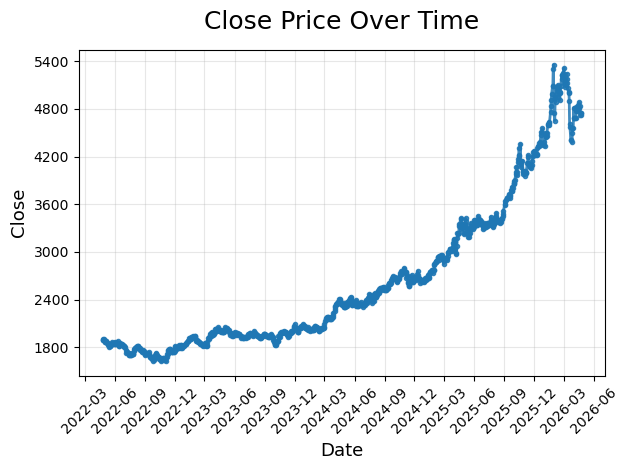

In [20]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


plt.plot(
    ts_combined["Date"],
    ts_combined["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Trend Analysis (Regression on Time)

In [21]:
ts_combined["time_index"] = np.arange(1, len(ts_combined) + 1)

X_time = ts_combined[["time_index"]]
y_time = ts_combined["Close"]

trend_model = LinearRegression()
trend_model.fit(X_time, y_time)

trend_pred = trend_model.predict(X_time)

trend_r2 = r2_score(y_time, trend_pred)
trend_rmse = np.sqrt(mean_squared_error(y_time, trend_pred))

In [22]:
print(f"Intercept: {trend_model.intercept_:.2f}")
print(f"Slope: {trend_model.coef_[0]:.4f}")
print(f"R-squared: {trend_r2:.4f}")
print(f"RMSE: {trend_rmse:.4f}")

Intercept: 1152.71
Slope: 2.9477
R-squared: 0.8247
RMSE: 395.4914


#### Meaning:

- on average, the adjusted close increases by about 2.9477 per business-day step**
- the upward trend is present, but not all variation is explained by a straight line
- this is expected, because market prices are noisy and time dependence matters

## ARIMA model
- AR → autoregressive part, which uses past values
- I → integrated part, which applies differencing
- MA → moving-average part, which uses past forecast errors
  
#### The model is written as: `ARIMA(p,d,q)`
where: 
- `p` controls how many past values are used.
- `d` controls how many times the series is differenced.
- `q` controls how many past forecast errors are used.

In [25]:
from statsmodels.tsa.arima.model import ARIMA

ts_arima = ts_combined.set_index("Date").asfreq("B")

arima_model = ARIMA(ts_arima["Close"], order=(1, 1, 1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=3)

arima_forecast

2026-04-27    4742.197623
2026-04-28    4742.974112
2026-04-29    4743.438758
Freq: B, Name: predicted_mean, dtype: float64

## Prophet forecasting

In [27]:
from prophet import Prophet

df_prophet = ts_combined.rename(columns={"Date": "ds", "Close": "y"})

prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=3, freq="B")

forecast = prophet_model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

14:09:22 - cmdstanpy - INFO - Chain [1] start processing
14:09:23 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1008,2026-04-27,5147.006674,5008.627701,5283.277543
1009,2026-04-28,5153.596457,5016.992207,5286.687875
1010,2026-04-29,5162.164054,5036.750977,5295.243224


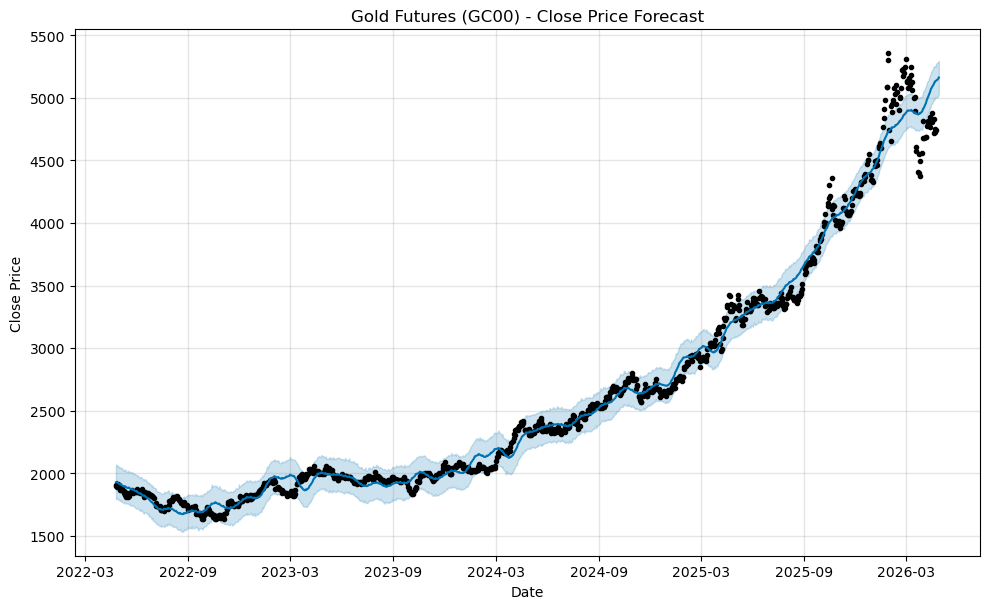

In [28]:
prophet_model.plot(forecast)
plt.title("Gold Futures (GC00) - Close Price Forecast")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

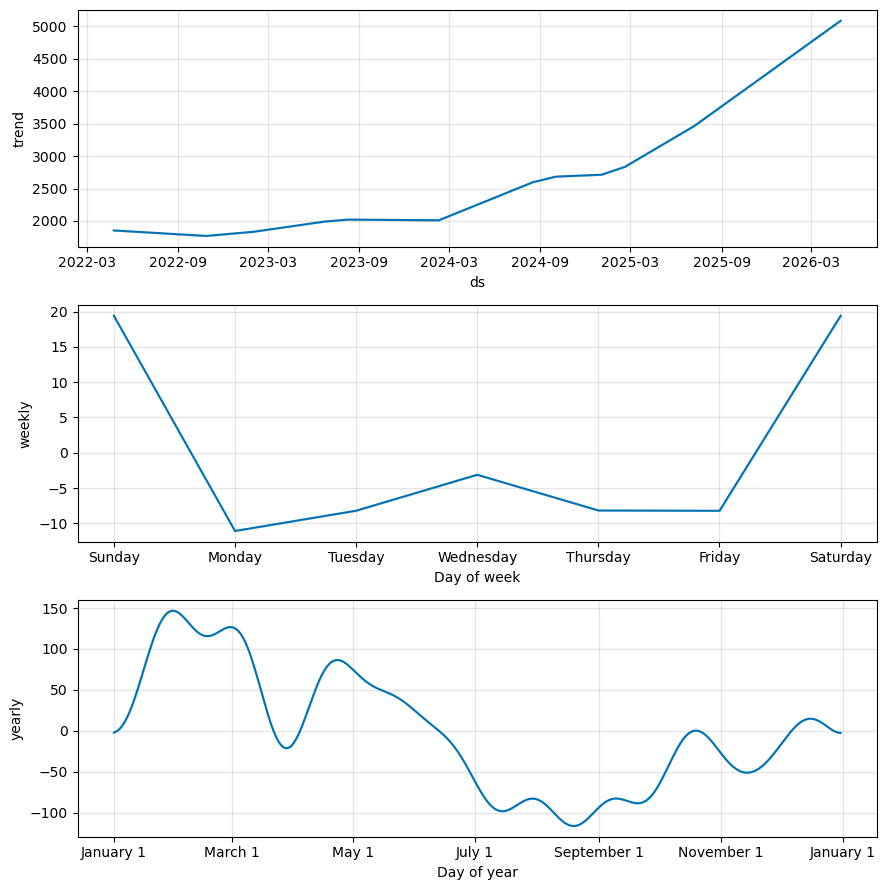

In [29]:
prophet_model.plot_components(forecast)
plt.show()